 データを準備する．

 ここでは4つの2次元データにそれぞれ'A'から'D'までのラベルが振ってある．

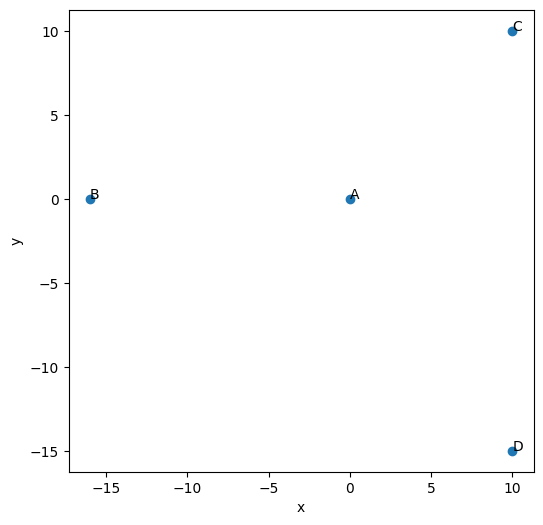

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy

my_data = pd.DataFrame(
    {'x': [  0, -16,  10,  10],
     'y': [  0,   0,  10, -15]},
    index=['A', 'B', 'C', 'D'])

# 散布図で様子見
plt.subplots(figsize=(6, 6))
plt.scatter(my_data['x'], my_data['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.annotate('A', (0, 0))
plt.annotate('B', (-16, 0))
plt.annotate('C', (10, 10))
plt.annotate('D', (10, -15))
plt.show()

In [ ]:
# クラスタリングの実行
my_result = hierarchy.linkage(
    my_data,
    metric='euclidean', # 省略可
    method='complete')

{'icoord': [[25.0, 25.0, 35.0, 35.0],
  [15.0, 15.0, 30.0, 30.0],
  [5.0, 5.0, 22.5, 22.5]],
 'dcoord': [[0.0, 14.142135623730951, 14.142135623730951, 0.0],
  [0.0, 25.0, 25.0, 14.142135623730951],
  [0.0, 30.01666203960727, 30.01666203960727, 25.0]],
 'ivl': ['B', 'D', 'A', 'C'],
 'leaves': [1, 3, 0, 2],
 'color_list': ['C1', 'C0', 'C0'],
 'leaves_color_list': ['C0', 'C0', 'C1', 'C1']}

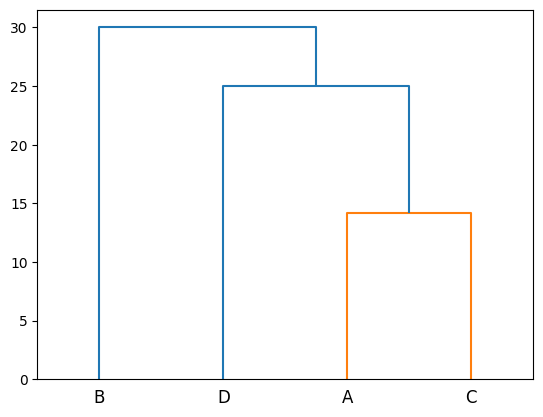

In [ ]:
#階層的クラスタリングの結果をデンドログラム（樹形図）で可視化する
hierarchy.dendrogram(my_result, labels=my_data.index)

まず，最も近い $A$ と $C$ がクラスタ $\{ A, C\}$になる．

次にクラスタ $\{ A, C\}$ と点 $B$, 点 $D$ の距離を考える．

クラスタ $\{ A, C\}$ と点 $B$ の距離は，$\overline{AB}$ と $\overline{CB}$ の大きい方，つまり点 $C$ と点 $B$ の距離で代用する．

同様に，$\{ A, C\}$ と点 $D$ の距離は，点 $C$ と点 $D$ の距離で代用する．

すると，クラスタ $\{ A, C\}$，点 $B$，点 $D$ で近いのは $\{ A, C\}$ と 点 $D$ になる．これらをまとめてクラスタ $\{D, A, C\}$ となる．

以上の過程を可視化したものが，デンドログラムというわけである．

ただし，このデンドログラムで $A$ と $C$ が似ていることは（距離が近いので）分かるのだが，$A$ と $D$ が似ているかどうかは分からない． つまり，$A$ と $D$ がデンドログラム上で隣り合っているのは $A$ と $D$ が似ているからではなく，クラスタ $\{ A, C\}$  と $D$ が近かったからに過ぎない．

もちろん，クラスタどうしの距離の決め方には選択肢がある．

上の例では，クラスタ $\{ A, C\}$ と点 $B$ の距離 を $\overline{AB}$ と $\overline{CB}$ の大きい方で代用した．



クラスタ数を3にする場合に，各点がどのクラスタに属しているかを確認する．

In [ ]:
hierarchy.cut_tree(my_result, 3)

array([[0],
       [1],
       [0],
       [2]])

In [ ]:
# （見やすくする）
my_data.assign(cluster=hierarchy.cut_tree(my_result, 3))

,x,y,cluster
A,0,0,0
B,-16,0,1
C,10,10,0
D,10,-15,2


ではクラスタ数を2にしてみる．

点A, C, Dが同じクラスに属していることが分かる（デンドログラムの通り）．

In [ ]:
# （見やすくする）
my_data.assign(cluster=hierarchy.cut_tree(my_result, 2))

,x,y,cluster
A,0,0,0
B,-16,0,1
C,10,10,0
D,10,-15,0


このようにクラスタ数をあとで指定できるのも，階層的クラスタリングの利点の一つ．